In [1]:
import pandas as pd 
df = pd.read_csv("twitter_multi_class_sentiment.csv")
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [2]:
df['label_name'].value_counts()

label_name
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

In [3]:
df.shape

(16000, 3)

In [4]:
df['label'].unique()

array([0, 3, 2, 5, 4, 1], dtype=int64)

In [5]:
df.describe()

,label
count,16000.000000
mean,1.565937
std,1.501430
min,0.000000
25%,0.000000
50%,1.000000
75%,3.000000
max,5.000000


<Axes: xlabel='label_name'>

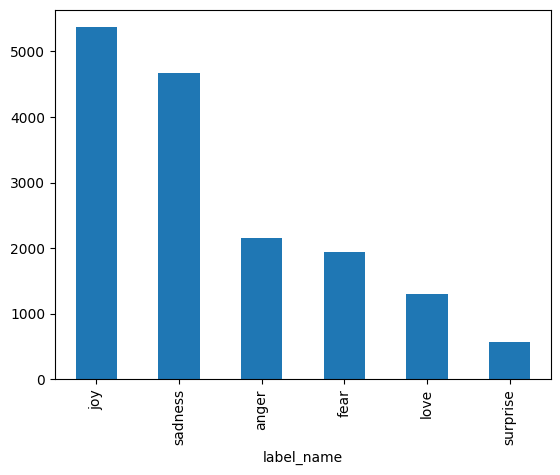

In [6]:
df['label_name'].value_counts().plot(kind = 'bar')

In [7]:
df['words_per_tweet'] = df['text'].str.split().apply(len)
df

,text,label,label_name,words_per_tweet
0,i didnt feel humiliated,0,sadness,4
1,i can go from feeling so hopeless to so damned...,0,sadness,21
2,im grabbing a minute to post i feel greedy wrong,3,anger,10
3,i am ever feeling nostalgic about the fireplac...,2,love,18
4,i am feeling grouchy,3,anger,4
...,...,...,...,...
15995,i just had a very brief time in the beanbag an...,0,sadness,24
15996,i am now turning and i feel pathetic that i am...,0,sadness,20
15997,i feel strong and good overall,1,joy,6
15998,i feel like this was such a rude comment and i...,3,anger,14


In [8]:
import matplotlib.pyplot as plt 
import seaborn as sns 

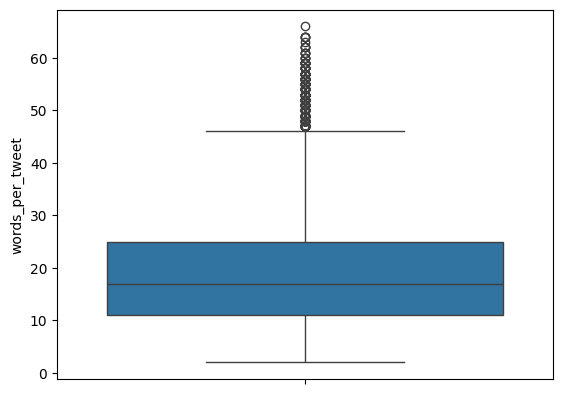

In [9]:
sns.boxplot(df['words_per_tweet'])
plt.show()

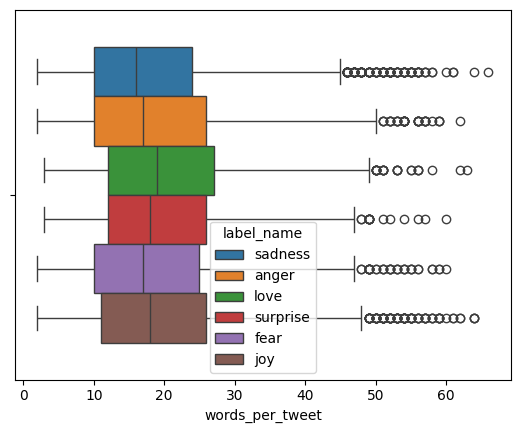

In [10]:
sns.boxplot(data = df , x = 'words_per_tweet' , hue = df['label_name'])
plt.show()

### Do the tokenization

In [11]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [12]:
tokenizer("I am leaning nlp." , "Nlp is complex than cv i think.")

{'input_ids': [101, 1045, 2572, 6729, 17953, 2361, 1012, 102, 17953, 2361, 2003, 3375, 2084, 26226, 1045, 2228, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

- input_ids:
    - Integer indices into BERT’s WordPiece vocabulary.
    - Each number corresponds to one token.
    - [CLS] token id 101,Sentence-level representation (classification head reads this).
    - [SEP] token id 102, Sentence boundary/end marker
- token_type_ids:
    - this is segment ids indicates which sentence a token belongs to.
    - 0 means sentence A and 1 means sentence B 1 means sentence B
- attention_mask:
    - Binary mask indicating which tokens are real
    - Controls self-attention computation, 1 means Real token(attend to it), 0 means Padding tokens(ignore it).

### Data Loader and Train Test Split

In [13]:
df.head()

,text,label,label_name,words_per_tweet
0,i didnt feel humiliated,0,sadness,4
1,i can go from feeling so hopeless to so damned...,0,sadness,21
2,im grabbing a minute to post i feel greedy wrong,3,anger,10
3,i am ever feeling nostalgic about the fireplac...,2,love,18
4,i am feeling grouchy,3,anger,4


In [14]:
from sklearn.model_selection import train_test_split
train_data , test_data = train_test_split(
    df , test_size = 0.3, random_state = 42, stratify = df['label_name']
)
validation_data , test_data = train_test_split(
    test_data , test_size = 0.5 , random_state = 42, stratify = test_data['label_name']
)

In [15]:
train_data.shape , test_data.shape , validation_data.shape

((11200, 4), (2400, 4), (2400, 4))

In [16]:
from datasets import Dataset , DatasetDict

In [17]:
dataset = DatasetDict({
    'train': Dataset.from_pandas(train_data , preserve_index = False), 
    'test': Dataset.from_pandas(test_data, preserve_index = False), 
    'validation': Dataset.from_pandas(validation_data, preserve_index = False)
})
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_name', 'words_per_tweet'],
        num_rows: 11200
    })
    test: Dataset({
        features: ['text', 'label', 'label_name', 'words_per_tweet'],
        num_rows: 2400
    })
    validation: Dataset({
        features: ['text', 'label', 'label_name', 'words_per_tweet'],
        num_rows: 2400
    })
})

## Tokenization of the Emotion/sentiments

In [18]:
dataset['train'][0]

{'text': 'i feel unhappy it is no help for me that other persons say that i am happy how much truth there may be in it',
 'label': 0,
 'label_name': 'sadness',
 'words_per_tweet': 25}

In [19]:
MAX_LEN = 512 # defult tokenizer length in BERT paper
def tokenize(batch): 
    tokens = tokenizer(
        batch['text'], padding = True, 
        max_length = MAX_LEN, truncation = True
    )
    return tokens

In [20]:
tokenizer(dataset['train'][0]['text'])

{'input_ids': [101, 1045, 2514, 12511, 2009, 2003, 2053, 2393, 2005, 2033, 2008, 2060, 5381, 2360, 2008, 1045, 2572, 3407, 2129, 2172, 3606, 2045, 2089, 2022, 1999, 2009, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [21]:
tokenize(dataset['train'][0])

{'input_ids': [101, 1045, 2514, 12511, 2009, 2003, 2053, 2393, 2005, 2033, 2008, 2060, 5381, 2360, 2008, 1045, 2572, 3407, 2129, 2172, 3606, 2045, 2089, 2022, 1999, 2009, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [22]:
emotion_encoded = dataset.map(tokenize , batched = True, batch_size = None)

Map:   0%|          | 0/11200 [00:00<?, ? examples/s]

Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

In [23]:
emotion_encoded

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_name', 'words_per_tweet', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 11200
    })
    test: Dataset({
        features: ['text', 'label', 'label_name', 'words_per_tweet', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2400
    })
    validation: Dataset({
        features: ['text', 'label', 'label_name', 'words_per_tweet', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2400
    })
})

In [24]:
dataset['train'][ : 2]

{'text': ['i feel unhappy it is no help for me that other persons say that i am happy how much truth there may be in it',
  'i was feeling brave when i bought it and clearly when i was doing my makeup'],
 'label': [0, 1],
 'label_name': ['sadness', 'joy'],
 'words_per_tweet': [25, 16]}

In [25]:
tokenize(dataset['train'][ : 2])

{'input_ids': [[101, 1045, 2514, 12511, 2009, 2003, 2053, 2393, 2005, 2033, 2008, 2060, 5381, 2360, 2008, 1045, 2572, 3407, 2129, 2172, 3606, 2045, 2089, 2022, 1999, 2009, 102], [101, 1045, 2001, 3110, 9191, 2043, 1045, 4149, 2009, 1998, 4415, 2043, 1045, 2001, 2725, 2026, 5789, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]]}

In [26]:
# label2id and id2label mapping 
label2id = {x['label_name'] : x['label'] for x in dataset['train']}
id2label = {val : key for key , val in label2id.items()}

In [27]:
label2id

{'sadness': 0, 'joy': 1, 'fear': 4, 'surprise': 5, 'anger': 3, 'love': 2}

In [28]:
id2label

{0: 'sadness', 1: 'joy', 4: 'fear', 5: 'surprise', 3: 'anger', 2: 'love'}

### Model Building

In [29]:
from transformers import AutoModel
import torch

In [30]:
# load bert model 
model = AutoModel.from_pretrained('bert-base-uncased')

In [31]:
model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

In [32]:
from transformers import AutoModelForSequenceClassification, AutoConfig

In [33]:
num_labels = len(label2id)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [34]:
config = AutoConfig.from_pretrained(
    'bert-base-uncased', 
    label2id = label2id, 
    id2label = id2label
)
config

BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "sadness",
    "1": "joy",
    "2": "love",
    "3": "anger",
    "4": "fear",
    "5": "surprise"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "anger": 3,
    "fear": 4,
    "joy": 1,
    "love": 2,
    "sadness": 0,
    "surprise": 5
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.57.6",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

In [35]:
model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased', config = config
).to(device)
model

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

### Top Level Structure 
---
BertForSequenceClassification <br>
│
├── bert               ← Encoder backbone <br>
│   ├── embeddings<br>
│   ├── encoder<br>
│   │   └── layer[i]   ← Transformer blocks<br>
│   └── pooler<br>
│
├── dropout<br>
└── classifier         ← Task head<br>


In [36]:
model.classifier

Linear(in_features=768, out_features=6, bias=True)

In [37]:
model.config

BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "dtype": "float32",
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "sadness",
    "1": "joy",
    "2": "love",
    "3": "anger",
    "4": "fear",
    "5": "surprise"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "anger": 3,
    "fear": 4,
    "joy": 1,
    "love": 2,
    "sadness": 0,
    "surprise": 5
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.57.6",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

In [38]:
model.config_class

transformers.models.bert.configuration_bert.BertConfig

In [39]:
from transformers import TrainingArguments

In [67]:
batch_size = 64
training_dir = 'ber_base_train_dir'

training_args = TrainingArguments(
    output_dir = training_dir,
    overwrite_output_dir = True,
    num_train_epochs = 3,
    learning_rate = 2e-5,
    per_device_train_batch_size = batch_size,
    per_device_eval_batch_size = batch_size,
    weight_decay = 0.01,
    eval_strategy="epoch",
    disable_tqdm = False
)

In [41]:
!pip -q install evaluate

In [68]:
# build compute metrics 
import numpy as np
import evaluate

accuracy = evaluate.load('accuracy')

def compute_metrics(eval_pred): 
    predictions , labels = eval_pred
    predictions = np.argmax(predictions , axis = 1)
    return accuracy.compute(predictions = predictions , references = labels)

In [69]:
from sklearn.metrics import accuracy_score , f1_score

In [70]:
def compute_metrics_sklearn(pred): 
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    f1 = f1_score(labels , preds , average = 'weighted')
    acc = accuracy_score(labels , preds)
    return {
        "accuracy": acc,
        'f1_score': f1
    }

In [71]:
from transformers import Trainer, DataCollatorWithPadding

In [72]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=emotion_encoded["train"],
    eval_dataset=emotion_encoded["validation"],
    data_collator=data_collator,  
    compute_metrics=compute_metrics
)

In [73]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.257303,0.909167
2,No log,0.194873,0.915000
3,0.263700,0.185002,0.923333


TrainOutput(global_step=525, training_loss=0.2562523791903541, metrics={'train_runtime': 160.1518, 'train_samples_per_second': 209.801, 'train_steps_per_second': 3.278, 'total_flos': 1502253632275200.0, 'train_loss': 0.2562523791903541, 'epoch': 3.0})

In [74]:
# model evaluation 
pred_outputs = trainer.predict(
    emotion_encoded['test']
)
pred_outputs.metrics

{'test_loss': 0.15640538930892944,
 'test_accuracy': 0.9329166666666666,
 'test_runtime': 3.1428,
 'test_samples_per_second': 763.642,
 'test_steps_per_second': 12.091}

In [75]:
y_pred = np.argmax(pred_outputs.predictions , axis = 1)
y_true = emotion_encoded['test'][ : ]['label']

In [76]:
from sklearn.metrics import classification_report
report = classification_report(y_true , y_pred)

In [77]:
print(report)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       700
           1       0.96      0.93      0.94       804
           2       0.79      0.87      0.83       196
           3       0.95      0.93      0.94       324
           4       0.91      0.92      0.91       290
           5       0.86      0.79      0.82        86

    accuracy                           0.93      2400
   macro avg       0.90      0.90      0.90      2400
weighted avg       0.93      0.93      0.93      2400



In [78]:
text = "I am happy today because today I trained my first language model!!"
input_embedded = tokenizer(text, return_tensors = 'pt').to(device)

In [79]:
with torch.no_grad(): 
    outputs = model(**input_embedded)

In [80]:
outputs

SequenceClassifierOutput(loss=None, logits=tensor([[-0.3777,  5.5760, -0.3575, -0.7136, -1.5056, -1.4983]],
       device='cuda:0'), hidden_states=None, attentions=None)

In [81]:
logits = outputs.logits
logits

tensor([[-0.3777,  5.5760, -0.3575, -0.7136, -1.5056, -1.4983]],
       device='cuda:0')

In [82]:
label_id = torch.argmax(logits , dim = 1).item()
label_id

1

In [83]:
id2label[label_id]

'joy'

In [84]:
def do_prediction(text): 
    text = "I am happy today because today I trained my first language model!!"
    input_embedded = tokenizer(text, return_tensors = 'pt').to(device)
    with torch.no_grad(): 
        outputs = model(**input_embedded) 
    logits = outputs.logits
    label_id = torch.argmax(logits , dim = 1).item()
    return id2label[label_id]

In [85]:
do_prediction(text = "I am very sad.")

'joy'